In [519]:
import scipy

from src.utils import ingaas_processing
import numpy as np
import matplotlib.pyplot as plt

In [520]:
#scan_path = "F://Work//LIPI//scans//scan_20260226_152601.raw"
scan_path = "F://Work//LIPI//scans//outside//scan_20260319_142551.raw"
#scan_path = "F://Work//LIPI//scans//outside//scan_20260319_144342.raw"
#scan_path = "C://Users//jeppe//Documents//LIPI//scans//test2//scan_20260226_152601.raw"
#scan_path = "C://Users//jeppe//Documents//LIPI//scans//outside//scan_20260319_142551.raw"
cal_path = "data/calibration.npz"
K,P,DIM = ingaas_processing.load_calibration(cal_path)
scan = np.array(ingaas_processing.undistort(ingaas_processing.load_raw_image(scan_path, 640, 512), K, P, DIM))
frame_profile = np.sum(scan, axis=2)

453


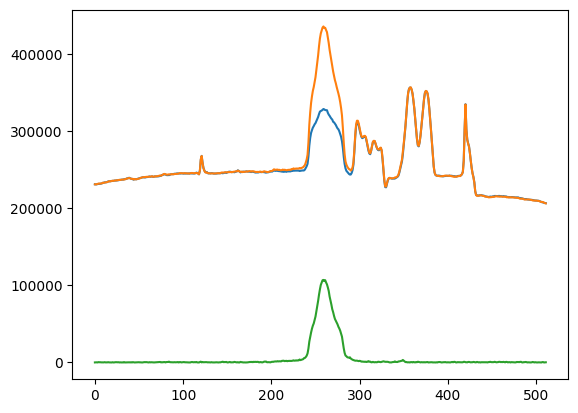

In [521]:
plt.plot(frame_profile[4001])
plt.plot(frame_profile[4000])
plt.plot(np.abs(frame_profile[4001]-frame_profile[4000]))
print(np.argmax(frame_profile[4001]-frame_profile[4000]))

260


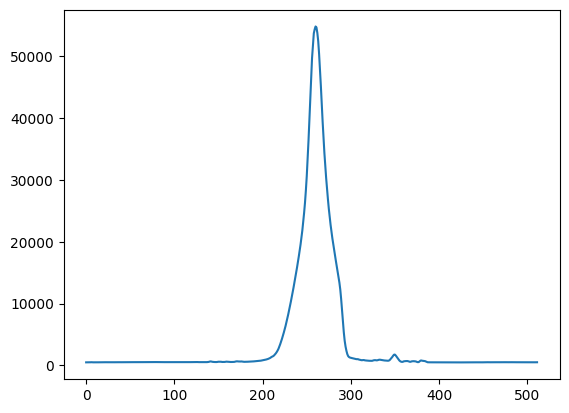

In [522]:
frame_profile = np.sum(scan, axis=2)
frame_diffs = frame_profile[1:]-frame_profile[:-1]
plt.plot(np.mean(np.abs(frame_diffs), axis=0))
lom = np.argmax(np.mean(np.abs(frame_diffs), axis=0))
print(lom)

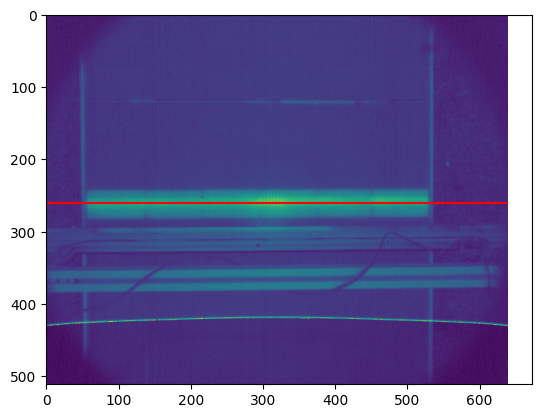

In [523]:
# print(np.min(scan), np.max(scan), scan.shape, scan.dtype)
plt.imshow(scan[4000])
plt.hlines(lom, 0, 640, "r")

In [524]:
scan_profile = frame_profile[:,279]

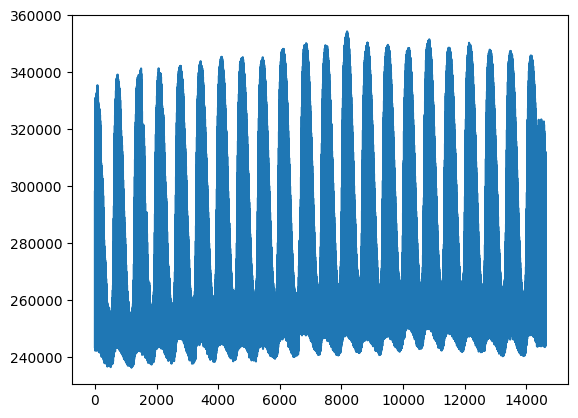

In [525]:
plt.plot(scan_profile)

In [526]:
# peaks, properties = scipy.signal.find_peaks(scan_profile, prominence=0, wlen=1000)
# sorted_index = np.argsort(properties["prominences"])
# peak_1 = peaks[sorted_index[-1]]
# peak_2 = peaks[sorted_index[-2]]
# print(peak_1, peak_2)
# module_start = min(peak_1, peak_2)
# module_end = max(peak_1, peak_2)
# plt.imshow(scan[module_start])
# plt.show()
# plt.imshow(scan[module_end])
# plt.show()

In [527]:
# #scipy envelope??
# #low pass filter or something to detect the large peaks then remove start and end of module for further analysis of the scan
#
# coffs = scipy.signal.butter(2, 1/60, output="sos", btype="lowpass")
# print(coffs)
# low_pass = scipy.signal.sosfilt(coffs, scan_profile)
# plt.plot(low_pass)
#
# peaks, properties = scipy.signal.find_peaks(low_pass, width=0, height=0)
# #plt.plot(peaks, scan_profile[peaks], ".")
# #print(properties["peak_heights"])
# sorted_index = np.argsort(properties["peak_heights"])
# module_start = min(peaks[sorted_index[-1]], peaks[sorted_index[-2]])
# module_end = max(peaks[sorted_index[-2]], peaks[sorted_index[-2]])
# #test_width = int(properties["widths"][sorted_index[-1]])
# print(module_start, module_end)
# plt.vlines((module_start, module_end), 0, np.max(low_pass), "r")
# width_end = properties["widths"][sorted_index[-1]]
# width_start = properties["widths"][sorted_index[-2]]
# print(width_start, width_end)
# plt.vlines((module_start+width_start, module_end-width_end), 0, np.max(low_pass), "g")
#
# plt.imshow(scan[int(module_start+width_start)])
# plt.show()
# plt.imshow(scan[int(module_end-width_start)+2])

[  19   23   31   33   35   44   47   49   58   61   63   65   90   93
   95   97  101  103  106  108  110  112  114  116  122  125  129  145
  158  161  163  166  170  173  191  194  199  203  206  209  214  225
  227  239  250  252  264  268  286  290  293  295  299  305  308  315
  317  332  357  360  364  367  387  389  392  395  397  401  403  406
  419  431  434  446  449  453  456  458  460  462  477  481  483  486
  488  490  492  494  496  498  501  503  506  538  545  573  576  579
  582  584  586  589  591  594  596  609  623  642  646  649  669  672
  674  676  678  680  684  686  690  695  727  738  740  742  744  769
  771  778  783  785  787  792  795  798  825  827  831  836  838  860
  863  865  867  869  871  875  877  880  882  892  921  927  930  933
  936  939  941  946  964  968  971  975  980  982  985  991  993 1016
 1023 1025 1030 1032 1035 1060 1062 1064 1067 1071 1075 1077 1079 1081
 1085 1096 1107 1114 1116 1120 1125 1127 1152 1154 1156 1161 1163 1167
 1169 

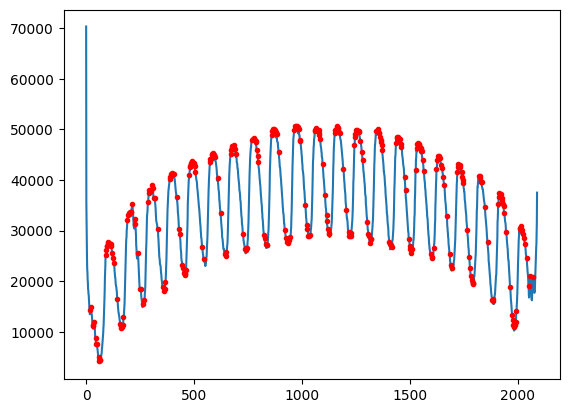

In [528]:
bp_in = (int(50*len(scan_profile)/f_s), None)
scan_env, scan_res = scipy.signal.envelope(scan_profile, bp_in, n_out = int(len(scan_profile)/7))
#plt.plot(scan_profile[trim_start:trim_start+12])
plt.plot(scan_env)
peaks_test, _ = scipy.signal.find_peaks(scan_env)
print(peaks_test)
plt.plot(peaks_test, scan_env[peaks_test], ".r")

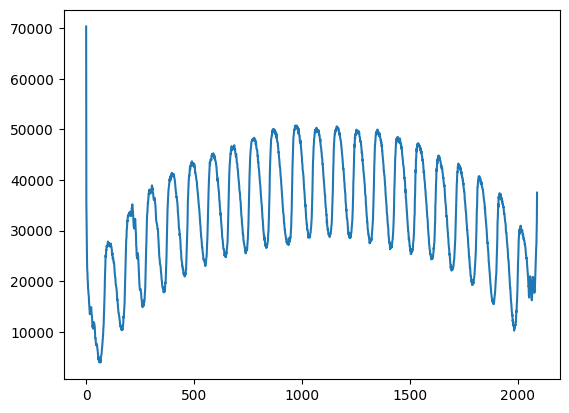

In [529]:
plt.plot(scan_env)
#plt.plot(scan_res)

In [530]:
line_profiles = scan[:, 279, :]
line_env, line_res = scipy.signal.envelope(line_profiles, bp_in, n_out = int(0.3*len(line_profiles)/(int(f_s/f_m))), axis=0)

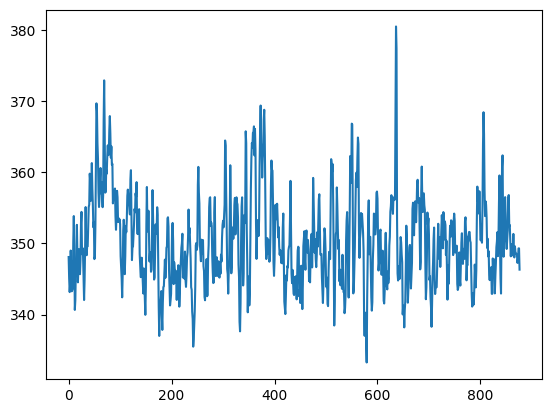

In [531]:
plt.plot(line_res[:,0])

In [532]:
# # #Vertical
# # v_profile = line_res.sum(axis=1)
# # plt.plot(v_profile)
# # v_peaks, v_peaks_prop = scipy.signal.find_peaks(v_profile, distance=10, prominence=10000, height=0)
# # #print(res_peaks_prop)
# # plt.plot(v_peaks, v_profile[v_peaks], ".r")
# # plt.show()
# # v_peaks_sort = np.argsort(v_peaks_prop["prominences"])
# # v_mod_start = min(v_peaks[v_peaks_sort[-1]], v_peaks[v_peaks_sort[-2]])
# # v_mod_end = max(v_peaks[v_peaks_sort[-1]], v_peaks[v_peaks_sort[-2]])
# #
# #
# # #Horizontal
# # h_profile = line_res.sum(axis=0)
# # plt.plot(h_profile)
# # h_peaks, h_peaks_prop = scipy.signal.find_peaks(h_profile, distance=10, prominence=70000, height=0)
# # plt.plot(h_peaks, h_profile[h_peaks], ".r")
# # plt.show()
# # h_mod_start = h_peaks[0]
# # h_mod_end = h_peaks[-1]
#
# #Final
# module = line_res[v_mod_start:v_mod_end, h_mod_start:h_mod_end]
# module = line_env
# plt.imshow(module, cmap="gray")
# plt.show()
#
# #module_process = np.uint16(((module-module.min())/(module.max()-module.min()))*2**16)
# module_process = ingaas_processing.lin_stretch_img(module, 0.01, 99.9)
# print(module_process.min(), module_process.max())
# plt.imshow(module_process, cmap="gray")
# plt.show()

In [533]:
test = np.sum(scan, axis=(1,2))

In [534]:
#Functions
def get_phase(x, f, f_s, debug_out=False):
    '''
    Finds the phase of a given frequency in a signal, sampled at some other frequency.

    Args:
        x: The signal as a numpy array
        f: The frequency to find the phase of
        f_s: The frequency at which the signal was sampled
        debug_out: Whether to display some debug info

    Returns:
        phase: The phase of the signal
        f_out: The closest frequency present in the FFT

    '''

    # Where is the modulation frequency in the results?
    fft_frequencies = scipy.fft.fftshift(scipy.fft.rfftfreq(len(x), d=1/f_s))
    f_index = np.argmin(np.abs(f-fft_frequencies))
    f_out = fft_frequencies[f_index]
    if debug_out:
        print(f_index)
        print(f_out)

    # FFT of data
    yf = scipy.fft.fftshift(scipy.fft.rfft(x))
    if debug_out:
        plt.plot(fft_frequencies, yf)
        plt.show()


    # Get phase
    phase = np.angle(yf[f_index])
    if debug_out:
        print(yf[f_index])
        print("Phase:", phase)

    return phase, f_out

def get_extrema(f,phase,f_s,N):
    '''
    Estimate the extrema points of a discrete signal

    Args:
        f: Frequency of the signal component of interest
        phase: How the signal component is shifted. Should be in the range [-Pi,Pi]
        f_s: Frequency at which the signal is sampled
        start: Index at which to start return from
        end: Index at which to end return at

    Returns:
        peaks: Index of peaks as a numpy array
        valleys: Index of valleys as a numpy array

    '''
    #peak_arg = np.pi/4 - phase
    peak_arg =  -phase
    #valley_arg = 5*np.pi/4 - phase

    if peak_arg < 0:
        peak_arg += 2*np.pi
        #valley_arg += 2*np.pi

    if peak_arg > 2*np.pi:
        peak_arg -= 2*np.pi
        #valley_arg -= 2*np.pi

    valley_arg = peak_arg + np.pi

    base = np.arange(N)*2*np.pi
    peaks = np.round(f_s*(base+peak_arg)/(2*np.pi*f)).astype(np.int32)
    valleys = np.round(f_s*(base+valley_arg)/(2*np.pi*f)).astype(np.int32)

    #mask = np.all([peaks > start, peaks < end, valleys > start, valleys < end], axis=0)
    mask = np.all([peaks < N, valleys < N], axis=0)
    return peaks[mask], valleys[mask]

In [535]:
#Parameters
f_m = 50 #Hz
#f_s = 300 #Hz
f_s = 299.9 #Hz

start = 1800
wlen = round(f_s)
errors = []
phases = []
window = test[start:start + wlen]
#window = test
phase, f_out = get_phase(window, f_m, f_s)
errors.append((f_out-f_m)**2)
phases.append(phase)

print(phase,f_out)
peaks,valleys = get_extrema(f_m, phase, f_s, len(window))
print(peaks, valleys)

1.8500328442762761 49.98333333333333
[  4  10  16  22  28  34  40  46  52  58  64  70  76  82  88  94 100 106
 112 118 124 130 136 142 148 154 160 166 172 178 184 190 196 202 208 214
 220 226 232 238 244 250 256 262 268 274 280 286 292] [  7  13  19  25  31  37  43  49  55  61  67  73  79  85  91  97 103 109
 115 121 127 133 139 145 151 157 163 169 175 181 187 193 199 205 211 217
 223 229 235 241 247 253 259 265 271 277 283 289 295]


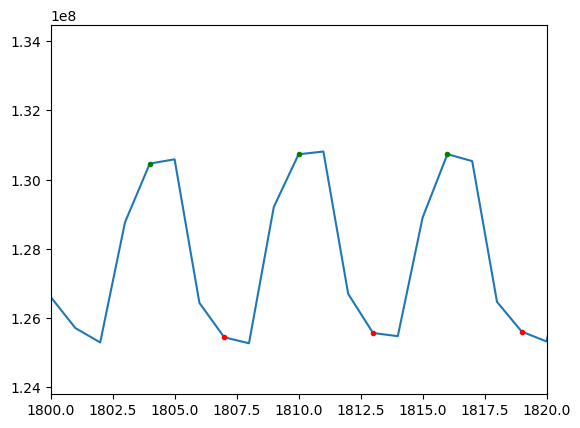

-1.01631234854947
1.9826876514505296


In [536]:
x_start=start
x_end=start+20

plt.plot(test)
plt.plot(peaks+start, test[peaks+start], ".g")
plt.plot(valleys+start, test[valleys+start], ".r")
plt.xlim(x_start, x_end)
plt.show()
# x = np.arange(len(test))
# y = np.sin(2*np.pi*x*f_m/f_s + phase) + np.cos(2*np.pi*x*f_m/f_s + phase)
# plt.xlim(x_start,x_end)
# plt.plot(x,y)
# plt.plot(peaks+start, y[peaks+start], ".g")
# plt.plot(valleys+start, y[valleys+start], ".r")
# plt.show()

print(f_s*(np.pi/4 - phase)/(2*np.pi*f_m))
print(f_s*(5*np.pi/4 - phase)/(2*np.pi*f_m))

In [537]:
data = scan
signal = np.sum(scan, axis=(1,2))

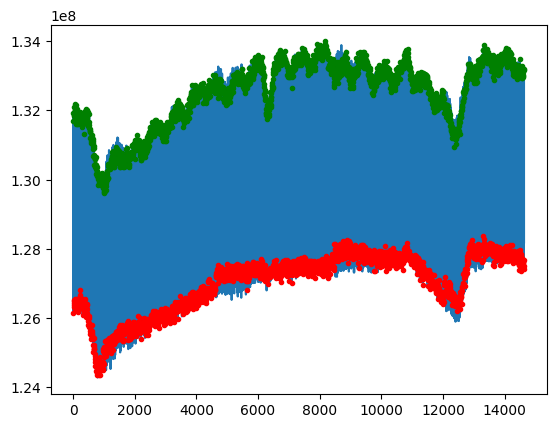

(array([-3, -2], dtype=int32), array([2154,    2]))
260


In [538]:
#Parameters
f_m = 50 #Hz
#f_s = 300 #Hz
f_s = 299.917668 #Hz

start = 0
wlen = 30

N = len(signal)

min_steps = np.ceil(N/wlen).astype(np.int32)
steps = 10+min_steps
step_size = (N-start-wlen)/(steps-1)
#print(step_size)

peaks = np.empty(0, dtype=np.int32)
valleys = np.empty(0, dtype=np.int32)
for i in range(steps):
    w_start = round(i*step_size)+start
    w_end = w_start+wlen
    w_start_next = round((i+1)*step_size)+start
    #print(w_start, w_end, w_start_next)
    if w_end+10 > N:
        w_start_next = w_end

    window = signal[w_start:w_end]
    phase, f_out = get_phase(window, f_m, f_s)
    peaks_i,valleys_i = get_extrema(f_m, phase, f_s, w_start_next-w_start)
    #print(peaks_i,valleys_i)
    peaks = np.append(peaks, peaks_i+w_start)
    valleys = np.append(valleys, valleys_i+w_start)

plt.plot(signal)
plt.plot(peaks, signal[peaks], ".g")
plt.plot(valleys, signal[valleys], ".r")
plt.show()

print(np.unique(peaks-valleys, return_counts=True))
frame_profile = np.sum(scan, axis=2)
frame_diffs = frame_profile[1:]-frame_profile[:-1]
#plt.plot(np.mean(np.abs(frame_diffs), axis=0))
lom = np.argmax(np.mean(np.abs(frame_diffs), axis=0))
print(lom)
result = data[peaks,:,:] - data[valleys,:,:]
stitch = result[:,lom,:]

[[362 326 326 ...  58 465 289]
 [270 307 107 ... 171 148 340]
 [293 350 370 ... 314 500  92]
 ...
 [232 367 394 ...  77 148 461]
 [302 214 304 ... 124 247  25]
 [291 347 259 ... 346 193 367]]


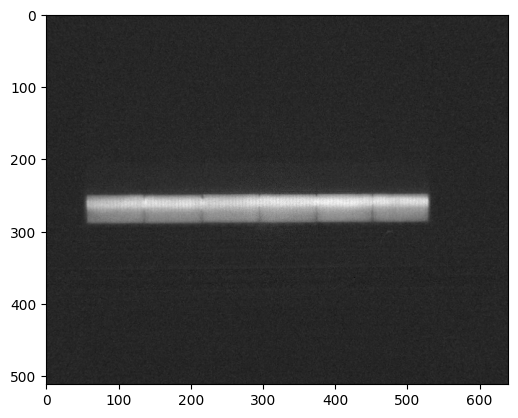

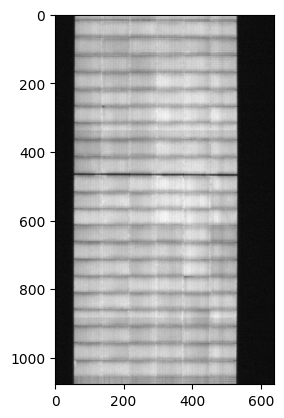

In [539]:
print(result.argmax(axis=1))
plt.imshow(result[900], cmap="gray")
plt.show()
plt.imshow(ingaas_processing.lin_stretch_img(stitch[::2,:], low_prc=0.03,high_prc=99.97), cmap="gray")

In [540]:
dist=3
prom = 10**6
peaks=scipy.signal.find_peaks(test, distance=dist,prominence=prom)[0]
valleys=scipy.signal.find_peaks(-test, distance=dist, prominence=prom)[0]
np.unique(peaks-valleys, return_counts=True)

(array([2, 3, 4]), array([ 602, 1798,   39]))

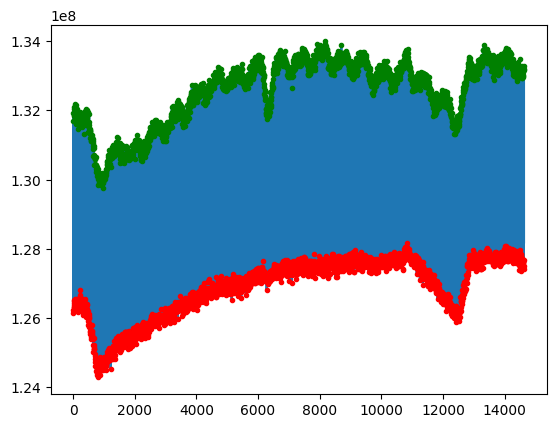

In [541]:
plt.plot(test)
plt.plot(peaks, test[peaks], ".g")
plt.plot(valleys, test[valleys], ".r")

In [542]:
#print(scan.shape)
test_out = scan[peaks, lom, :] - scan[valleys,lom,:]

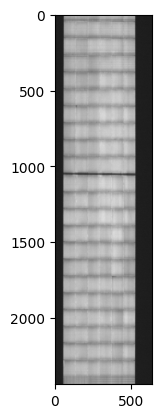

In [543]:
plt.imshow(test_out, cmap="gray")

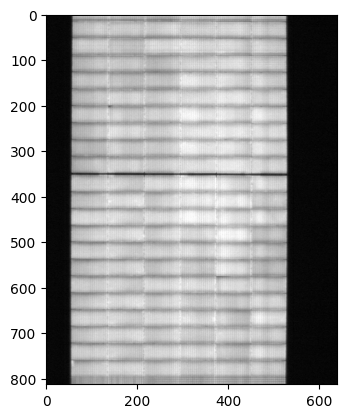

In [544]:
test_out_down = scipy.signal.decimate(test_out, 3, axis=0)
plt.imshow(ingaas_processing.lin_stretch_img(test_out_down, 0.1, 99.9), cmap="gray")

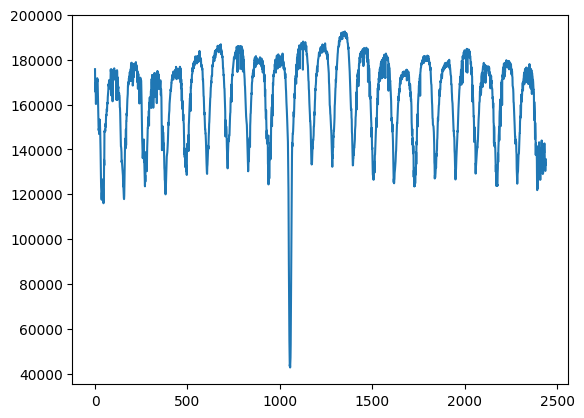

In [545]:
test_sum = np.sum(test_out,axis=1)
plt.plot(test_sum)
# peaks_out = scipy.signal.find_peaks(test_sum, distance=10)[0]
# plt.plot(peaks_out, test_sum[peaks_out], ".g")
# peaks_sorted = peaks_out[np.argsort(test_sum[peaks_out])]
# peak_1, peak_2 = peaks_sorted[0], peaks_sorted[-1]
# mod_start
# plt.plot(peaks_top_2, test_sum[peaks_top_2], ".r")

In [546]:
np.any(peaks==valleys)

np.False_

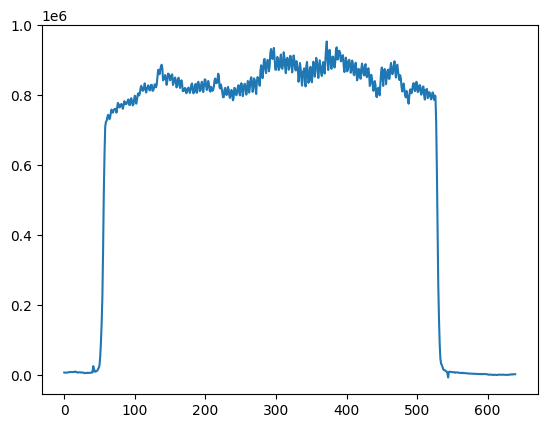

In [547]:
plt.plot(np.sum(test_out,axis=0))

In [548]:
filter_iir = scipy.signal.iirpeak(w0=50, Q=1, fs=f_s)
filtered_test = scipy.signal.filtfilt(filter_iir[0], filter_iir[1], scan[:, lom, :], axis=0)

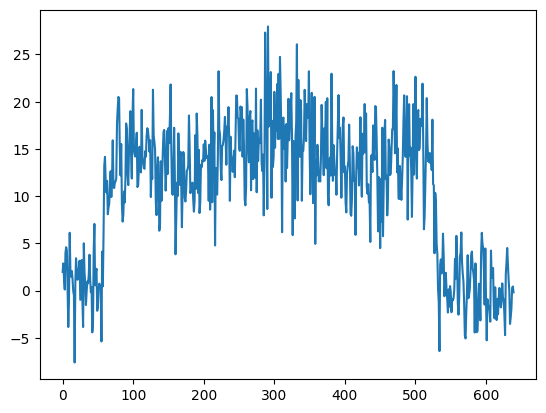

In [549]:
plt.plot(filtered_test[300])